In [1]:
!pip install easy-vqa transformers peft



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 66.4 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import models, transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

from transformers import DistilBertTokenizer, DistilBertModel

from easy_vqa import (
    get_train_questions,
    get_test_questions,
    get_train_image_paths,
    get_test_image_paths,
    get_answers
)


In [6]:
class EasyVQADataset(Dataset):
    def __init__(self, is_train=True):
        if is_train:
            self.questions, self.answers, self.image_ids = get_train_questions()
            self.image_paths = get_train_image_paths()
        else:
            self.questions, self.answers, self.image_ids = get_test_questions()
            self.image_paths = get_test_image_paths()

        self.all_answers = get_answers()
        self.ans_to_ix = {a: i for i, a in enumerate(self.all_answers)}
        self.ix_to_ans = {i: a for i, a in enumerate(self.all_answers)}

        self.transform = transforms.Compose([
            transforms.Resize((128, 128)),
            transforms.ToTensor()
        ])

        self.tokenizer = DistilBertTokenizer.from_pretrained(
            "distilbert-base-uncased"
        )

    def __len__(self):
        return len(self.questions)

    def __getitem__(self, idx):
        img = Image.open(
            self.image_paths[self.image_ids[idx]]
        ).convert("RGB")
        img = self.transform(img)

        enc = self.tokenizer(
            self.questions[idx],
            padding="max_length",
            truncation=True,
            max_length=15,
            return_tensors="pt"
        )

        label = self.ans_to_ix[self.answers[idx]]

        return (
            img,
            enc["input_ids"].squeeze(0),
            enc["attention_mask"].squeeze(0),
            torch.tensor(label)
        )


In [3]:
class VQAModel(nn.Module):
    def __init__(self, num_answers):
        super().__init__()

        # -------- Image Encoder --------
        effnet = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
        )
        self.cnn = effnet.features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        img_dim = 1280

        # -------- Text Encoder (PRETRAINED TRANSFORMER) --------
        self.text_encoder = DistilBertModel.from_pretrained(
            "distilbert-base-uncased"
        )
        txt_dim = 768

        # -------- Fusion --------
        self.mlp = nn.Sequential(
            nn.Linear(img_dim + txt_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_answers)
        )

    def forward(self, img, input_ids, attention_mask):
        # Image
        x = self.cnn(img)
        x = self.pool(x)
        img_feat = x.view(x.size(0), -1)

        # Text
        txt = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        ques_feat = txt.last_hidden_state.mean(dim=1)

        return self.mlp(torch.cat([img_feat, ques_feat], dim=1))


In [4]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for img, ids, mask, label in loader:
        img = img.to(device)
        ids = ids.to(device)
        mask = mask.to(device)
        label = label.to(device)

        optimizer.zero_grad()
        out = model(img, ids, mask)
        loss = criterion(out, label)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def eval_accuracy(model, loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for img, ids, mask, label in loader:
            img = img.to(device)
            ids = ids.to(device)
            mask = mask.to(device)
            label = label.to(device)

            preds = torch.argmax(model(img, ids, mask), dim=1)
            correct += (preds == label).sum().item()
            total += label.size(0)

    return correct / total


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

train_ds = EasyVQADataset(True)
test_ds  = EasyVQADataset(False)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=32)

model = VQAModel(num_answers=len(train_ds.all_answers)).to(device)

# 🔒 فریز DistilBERT (توصیه می‌شه)
for p in model.text_encoder.parameters():
    p.requires_grad = False

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-4
)

criterion = nn.CrossEntropyLoss()


Using: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

100%|██████████| 20.5M/20.5M [00:00<00:00, 98.3MB/s]


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
best_acc = 0
patience = 3
wait = 0

for epoch in range(10):
    loss = train_one_epoch(model, train_loader)
    acc = eval_accuracy(model, test_loader)

    print(f"Epoch {epoch+1:02d} | Loss {loss:.4f} | Acc {acc*100:.2f}%")

    if acc > best_acc:
        best_acc = acc
        best_state = model.state_dict()
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print("⛔ Early stopping")
            break

model.load_state_dict(best_state)


Epoch 01 | Loss 0.5246 | Acc 86.18%
Epoch 02 | Loss 0.3595 | Acc 86.82%
Epoch 03 | Loss 0.3504 | Acc 87.27%
Epoch 04 | Loss 0.3164 | Acc 88.14%
Epoch 05 | Loss 0.2976 | Acc 91.01%
Epoch 06 | Loss 0.2431 | Acc 93.64%
Epoch 07 | Loss 0.2021 | Acc 94.32%
Epoch 08 | Loss 0.1553 | Acc 95.72%
Epoch 09 | Loss 0.1266 | Acc 98.27%
Epoch 10 | Loss 0.1068 | Acc 98.41%


<All keys matched successfully>

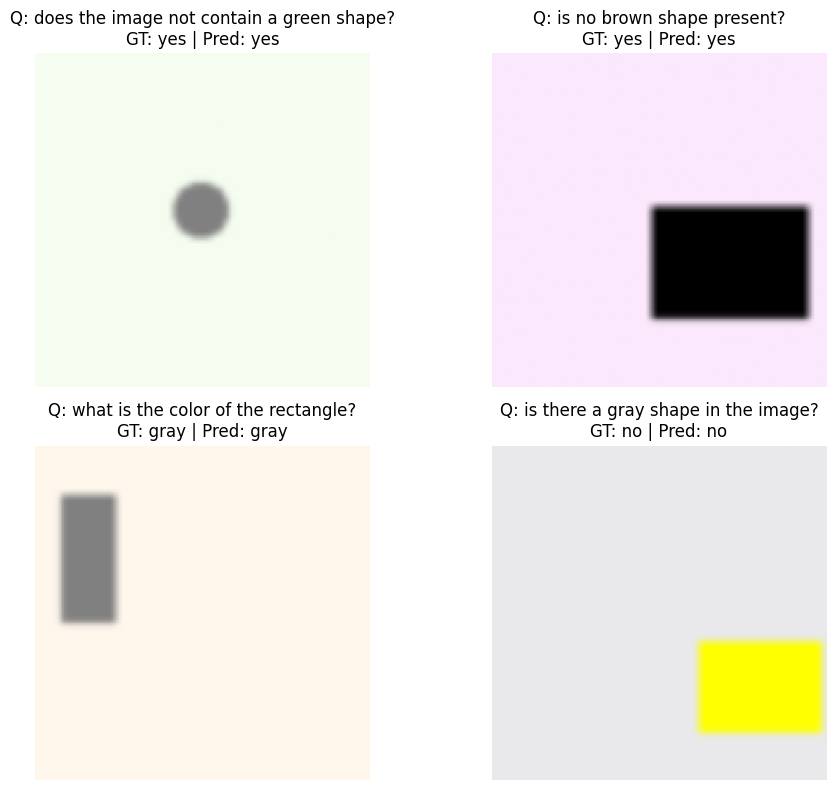

In [10]:
model.eval()
plt.figure(figsize=(10, 8))

for i in range(4):
    idx = np.random.randint(0, len(test_ds))
    img, ids, mask, label = test_ds[idx]

    with torch.no_grad():
        pred = torch.argmax(
            model(
                img.unsqueeze(0).to(device),
                ids.unsqueeze(0).to(device),
                mask.unsqueeze(0).to(device)
            ),
            dim=1
        ).item()

    plt.subplot(2, 2, i + 1)
    plt.imshow(img.permute(1, 2, 0))
    plt.axis("off")
    plt.title(
        f"Q: {test_ds.questions[idx]}\n"
        f"GT: {test_ds.answers[idx]} | Pred: {test_ds.ix_to_ans[pred]}"
    )

plt.tight_layout()
plt.show()
